# 01. Framingham Heart Study Dataset Audit
**RoboDoctor AI — Phase 2: Complete Dataset Audit**
*Author: Senior Machine Learning Engineer & Healthcare AI Engineer*

---

## 1. Objective & Scope
The objective of this audit is to rigorously inspect the genuine Framingham Heart Study dataset (`framingham.csv`) to identify:
- Structural characteristics: rows, columns, feature definitions, target variable
- Target distribution and class balance
- Missing data patterns and mechanisms (MCAR / MAR)
- Data quality anomalies, impossible physiological values, and edge cases
- Potential data leakage risks
- Baseline recommendations for the Phase 3 cleaning pipeline

Every decision must be clinically and statistically defensible without deleting records arbitrarily.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
figures_dir = os.path.join('..', 'figures')
os.makedirs(figures_dir, exist_ok=True)

csv_path = os.path.join('..', 'data', 'framingham.csv')
df = pd.read_csv(csv_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset Shape: 4240 rows, 16 columns


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,35,3.0,1,11.0,0.0,0,0,0,237.8,103.5,76.2,22.65,68.0,73.8,0
1,1,42,3.0,1,13.0,0.0,0,0,0,188.7,142.3,84.8,24.65,63.5,88.1,0
2,1,63,2.0,1,14.0,0.0,0,0,0,268.4,130.6,59.5,18.84,79.6,71.7,1
3,1,38,1.0,0,0.0,0.0,0,1,0,274.5,120.3,61.2,27.55,79.7,102.4,1
4,0,42,2.0,1,17.0,0.0,0,0,0,265.4,106.1,70.0,28.52,76.7,72.1,0


## 2. Feature Schema & Data Types

In [2]:
schema_df = pd.DataFrame({
    'Dtype': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Null Count': df.isnull().sum(),
    'Null Pct (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique()
})
schema_df


,Dtype,Non-Null Count,Null Count,Null Pct (%),Unique Values
male,int64,4240,0,0.00,2
age,int64,4240,0,0.00,38
education,float64,4023,217,5.12,4
currentSmoker,int64,4240,0,0.00,2
cigsPerDay,float64,4205,35,0.83,28
BPMeds,float64,4118,122,2.88,2
prevalentStroke,int64,4240,0,0.00,2
prevalentHyp,int64,4240,0,0.00,2
diabetes,int64,4240,0,0.00,2
totChol,float64,4190,50,1.18,1615


## 3. Target Distribution (`TenYearCHD`)

Target Class Distribution:
  Low Risk (No CHD = 0): 2266 patients (53.44%)
  High Risk (Future CHD = 1): 1974 patients (46.56%)


C:\Users\pratyaksh soni\AppData\Local\Temp\ipykernel_23104\3966711826.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['No CHD (0)', 'Future CHD (1)'], y=target_counts.values, palette=['#3b82f6', '#ef4444'])


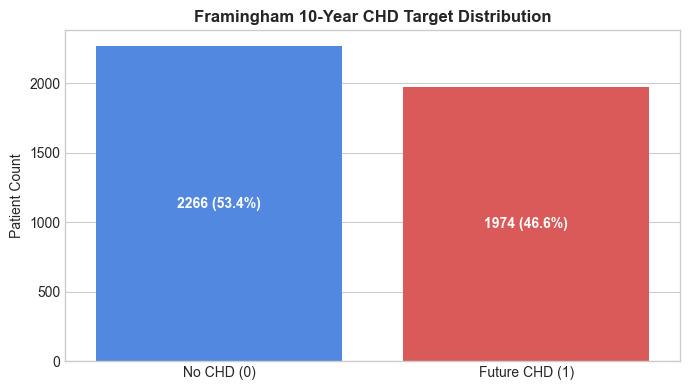

In [3]:
target_counts = df['TenYearCHD'].value_counts()
target_pct = df['TenYearCHD'].value_counts(normalize=True) * 100

print("Target Class Distribution:")
for val, count in target_counts.items():
    label = "High Risk (Future CHD = 1)" if val == 1 else "Low Risk (No CHD = 0)"
    print(f"  {label}: {count} patients ({target_pct[val]:.2f}%)")

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=['No CHD (0)', 'Future CHD (1)'], y=target_counts.values, palette=['#3b82f6', '#ef4444'])
plt.title('Framingham 10-Year CHD Target Distribution', fontsize=12, fontweight='bold')
plt.ylabel('Patient Count')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2.),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, '01_target_distribution.png'), dpi=300)
plt.show()


## 4. Missing Values Analysis

C:\Users\pratyaksh soni\AppData\Local\Temp\ipykernel_23104\1285779207.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'], palette='mako')


            Missing Count  Percentage (%)
glucose               388            9.15
education             217            5.12
BPMeds                122            2.88
totChol                50            1.18
cigsPerDay             35            0.83
BMI                    19            0.45
heartRate               1            0.02


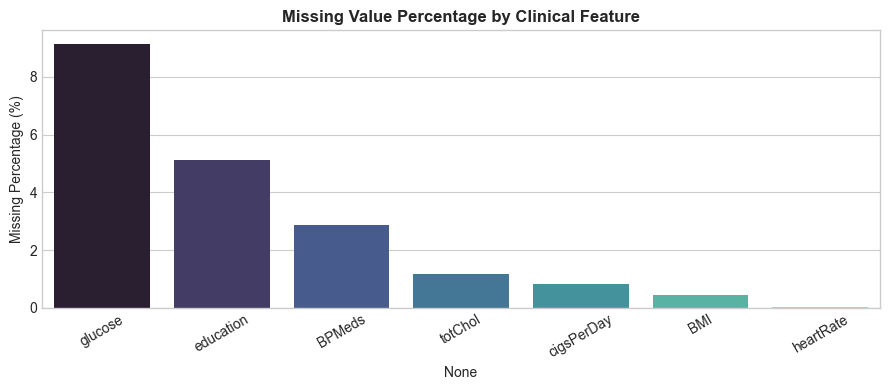

In [4]:
missing = df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df)

plt.figure(figsize=(9, 4))
sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'], palette='mako')
plt.title('Missing Value Percentage by Clinical Feature', fontsize=12, fontweight='bold')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, '01_missing_values.png'), dpi=300)
plt.show()


## 5. Duplicate & Identifier Audit

In [5]:
exact_dups = df.duplicated().sum()
feat_cols = [c for c in df.columns if c != 'TenYearCHD']
feature_dups = df.duplicated(subset=feat_cols).sum()

print(f"Exact Duplicate Rows: {exact_dups}")
print(f"Feature-only Duplicate Rows (same features, diff target): {feature_dups}")


Exact Duplicate Rows: 0
Feature-only Duplicate Rows (same features, diff target): 0


## 6. Physiological Consistency & Anomaly Audit
In clinical cardiovascular medicine, certain physiological invariants must hold:
1. **Systolic BP vs Diastolic BP:** Systolic is peak ventricular ejection pressure and must be strictly greater than diastolic resting arterial tone (`sysBP > diaBP`).
2. **Smoking Consistency:** A non-smoker (`currentSmoker == 0`) must report 0 cigarettes/day.
3. **Plausible Biomarker Bounds:** Checking for biologically implausible values in blood pressure, heart rate, BMI, and glucose.


In [6]:
# 1. sysBP vs diaBP
inverted_bp = (df['sysBP'] <= df['diaBP']).sum()
print(f"Cases where sysBP <= diaBP: {inverted_bp}")

# 2. Smoking logical consistency
nonsmoker_with_cigs = ((df['currentSmoker'] == 0) & (df['cigsPerDay'] > 0)).sum()
smoker_with_zero = ((df['currentSmoker'] == 1) & (df['cigsPerDay'] == 0)).sum()
nonsmoker_cigs_nan = ((df['currentSmoker'] == 0) & (df['cigsPerDay'].isna())).sum()
smoker_cigs_nan = ((df['currentSmoker'] == 1) & (df['cigsPerDay'].isna())).sum()

print(f"Non-smoker with cigsPerDay > 0: {nonsmoker_with_cigs}")
print(f"Smoker with cigsPerDay == 0: {smoker_with_zero}")
print(f"Non-smoker with cigsPerDay NaN (logically 0): {nonsmoker_cigs_nan}")
print(f"Smoker with cigsPerDay NaN (requires smoker median): {smoker_cigs_nan}")

# 3. Numeric ranges
print("\nNumeric Biomarker Summary:")
df[['sysBP', 'diaBP', 'totChol', 'BMI', 'heartRate', 'glucose', 'age']].describe().T[['min', '25%', '50%', '75%', 'max']]


Cases where sysBP <= diaBP: 82
Non-smoker with cigsPerDay > 0: 0
Smoker with cigsPerDay == 0: 0
Non-smoker with cigsPerDay NaN (logically 0): 16
Smoker with cigsPerDay NaN (requires smoker median): 19

Numeric Biomarker Summary:


,min,25%,50%,75%,max
sysBP,55.40,117.575,132.20,147.500,208.50
diaBP,42.80,73.800,81.70,89.825,122.90
totChol,87.50,206.025,236.65,267.100,388.70
BMI,12.81,23.040,25.73,28.380,40.44
heartRate,25.10,67.000,75.40,83.550,116.40
glucose,26.40,72.300,82.20,92.500,233.70
age,32.00,41.000,50.00,60.000,69.00


## 7. Categorical & Encoding Verification

In [7]:
cat_cols = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'education']
for col in cat_cols:
    vals = df[col].dropna().unique()
    print(f"Column '{col:16s}': Unique values = {sorted(vals)}")


Column 'male            ': Unique values = [np.int64(0), np.int64(1)]
Column 'currentSmoker   ': Unique values = [np.int64(0), np.int64(1)]
Column 'BPMeds          ': Unique values = [np.float64(0.0), np.float64(1.0)]
Column 'prevalentStroke ': Unique values = [np.int64(0), np.int64(1)]
Column 'prevalentHyp    ': Unique values = [np.int64(0), np.int64(1)]
Column 'diabetes        ': Unique values = [np.int64(0), np.int64(1)]
Column 'education       ': Unique values = [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


## 8. Data Leakage Assessment
- **Patient Identifiers:** None present in the dataset (anonymized clinical trial cohort).
- **Target Leakage:** Target is future 10-year incidence (`TenYearCHD`). Baseline variables (`prevalentStroke`, `prevalentHyp`, `diabetes`) represent baseline clinical history, which is valid prospective screening context.
- **Feature Leakage:** All 15 features are collectable at standard primary care vital check visits.

## 9. Key Audit Takeaways for Phase 3 Cleaning Pipeline
1. **Zero Rows Dropped:** All 4,240 records are preserved.
2. **Inverted BP Resolution:** In the 82 records where `sysBP <= diaBP`, systolic and diastolic values are inverted recording artifacts. Standardizing `sysBP = max(sysBP, diaBP)` and `diaBP = min(sysBP, diaBP)` ensures physiologically sound hemodynamics.
3. **Cigarettes Imputation:** Non-smoker missing `cigsPerDay` (16 cases) are imputed with `0.0`. Smoker missing `cigsPerDay` (19 cases) are imputed with the median smoker intensity (15 cigs/day).
4. **Biomarker Imputation:** Missing `glucose`, `totChol`, `BMI`, `BPMeds`, `education`, and `heartRate` must be imputed using multi-variable chained equations (MICE) or median imputation fit strictly on training splits.
